# Assignment 4 – Portugal | Part 1: Eligibility Analysis

Outputs saved to disk for `PyPSA.ipynb` and `Visualizations.ipynb`.

### 1. Import of the most important libraries

In [1]:
import numpy as np
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
import warnings; warnings.filterwarnings('ignore')
import os, unicodedata
import cartopy.crs as ccrs, cartopy
import atlite, xarray as xr, rasterio, requests
from rasterio.transform import from_bounds
from atlite.gis import ExclusionContainer
from shapely.geometry import box
from atlite.gis import shape_availability
import rasterio.plot
from shapely.geometry import box as shp_box

### 2. Downloading relevant fils that are stored and accessible via tuCloud

In [3]:
url_dataset = 'https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq' #repository
url_airports = f'{url_dataset}/download?path=%2F&files=ne_10m_airports.gpkg' #10 km to airports
url_roads = f'{url_dataset}/download?path=%2F&files=ne_10m_roads.gpkg' #300m distance to roads
url_gadm = f'{url_dataset}/download?path=%2Fgadm&files=gadm_410-levels-ADM_1-PRT.gpkg' #administrative regions per country
url_wdpa = f'{url_dataset}/download?path=%2Fwdpa&files=WDPA_Oct2022_Public_shp-PRT.tif' #protected areas
url_gebco = f'{url_dataset}/download?path=%2Fgebco&files=GEBCO_2014_2D-PT.nc' #elevation data
url_glc = f'{url_dataset}/download?path=%2Fcopernicus-glc&files=PROBAV_LC100_global_v3.0.1_2019-nrt_Discrete-Classification-map_EPSG-4326-PT.tif' #land covr types
url_eez = f'{url_dataset}/download?path=%2Fmarineregions%2FWorld_EEZ_v11_20191118_gpkg&files=eez_v11.gpkg' #within EEZ
url_country_shapes = f'{url_dataset}/download?path=%2F&files=country_shapes.geojson'

## 1. Shapes & Regions

Loading country shapes and reprojecting it to the coordinate reference system PSG:3035

In [4]:
countries = gpd.read_file(url_country_shapes).set_index('name') #loading country shapes for world
country_shape = countries.loc[['PT'], 'geometry'].to_crs(3035) # [EPSG:3035, m], selecting portugal, reprojection via EPSG:3035, only keeping the geometry column
country_shape #output country shape

name
PT    POLYGON ((2831438.053 1912762.934, 2830052.451...
Name: geometry, dtype: geometry

Splitting country in (at least) 5 rgions on which all further modelling will build. For each region a represntative point is chosn. xtract shape of the EEZ, since not landlocked

In [5]:
regions_raw = gpd.read_file(url_gadm).to_crs(3035) #using GADM dataset to split portugal into regions

nuts2_mapping = {
    'Norte':    ['Braga','Braganca','Porto','Viana do Castelo','Vila Real'], #region 1 the north
    'Centro':   ['Aveiro','Castelo Branco','Coimbra','Guarda','Leiria','Viseu','Santarem'], #region 2 the center
    'Lisboa':   ['Lisboa','Setubal'], #region 3 Lisboa
    'Alentejo': ['Beja','Evora','Portalegre'], #region 4 Alentejo
    'Algarve':  ['Faro'], #region 5 Algarve
} #the Azores are islands and therefore excluded in mapping

nuts2_mapping

{'Norte': ['Braga', 'Braganca', 'Porto', 'Viana do Castelo', 'Vila Real'],
 'Centro': ['Aveiro',
  'Castelo Branco',
  'Coimbra',
  'Guarda',
  'Leiria',
  'Viseu',
  'Santarem'],
 'Lisboa': ['Lisboa', 'Setubal'],
 'Alentejo': ['Beja', 'Evora', 'Portalegre'],
 'Algarve': ['Faro']}

In [6]:
#function to clean up accents from the strings
def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFD', str(s)) if unicodedata.category(c) != 'Mn')

#adjustments so every point is assigned to a specific region (one of the above defined)
district_to_nuts2 = {d: k for k, v in nuts2_mapping.items() for d in v}

#new column to regions raw that maps districs to nuts2 region
regions_raw['nuts2'] = regions_raw['NAME_1'].apply(strip_accents).map(district_to_nuts2)
regions = regions_raw.dropna(subset = ['nuts2']).dissolve('nuts2')[['geometry']] # [EPSG:3035, m], dropping Azores and Madeira, since returning NaN
regions['representative_point'] = regions.geometry.representative_point() # [EPSG:3035, m], guarantees a point as representative within the geometry
regions

,geometry,representative_point
nuts2,,
Alentejo,"MULTIPOLYGON (((2726815.031 1774790.872, 27267...",POINT (2775593.165 1894311.45)
Algarve,"MULTIPOLYGON (((2642809.829 1757654.459, 26428...",POINT (2710120.511 1766588.899)
Centro,"MULTIPOLYGON (((2683741.374 1949010.02, 268373...",POINT (2789439.757 2057873.833)
Lisboa,"MULTIPOLYGON (((2637740.323 1950901.258, 26377...",POINT (2675404.078 1979232.176)
Norte,"MULTIPOLYGON (((2764029.832 2200543.414, 27640...",POINT (2857288.109 2224000.179)


In [7]:
fn_eez = 'eez_portugal.gpkg' #locally stored filtered file for portugal

#in case of previously ran code and locally stored file
if os.path.exists(fn_eez):
    eez = gpd.read_file(fn_eez).to_crs(3035) # [EPSG:3035, m], reading locally stored file

#first run of script downloads the global eez file
else:
    eez = gpd.read_file(url_eez).to_crs(3035) # [EPSG:3035, m], loading file from url and projecting it via EPSG:3035
    eez = eez[eez['SOVEREIGN1'] == 'Portugal'] #filter portugal
    eez.to_file(fn_eez, driver = 'GPKG') #save locally for later

mb = country_shape.total_bounds # [m], mainland bounds (minx, miny, maxx, maxy)
clip_box = box(mb[0] - 300000, mb[1] - 50_000, mb[2] + 50000, mb[3] + 50000) # [m], define box around mainland (buffer)
eez_mainland = eez.clip(clip_box) # [EPSG:3035, m], cuts out everything outside the predefined box - only mainland + buffer remains

Plotting results of region definition and EEZ

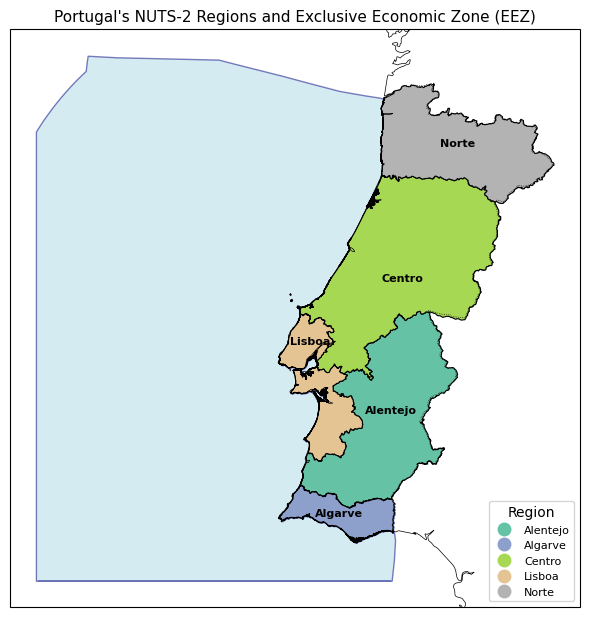

In [8]:
fig, ax = plt.subplots(figsize=(6, 9), subplot_kw={'projection': ccrs.epsg(3035)})

eez_mainland.plot(ax = ax, edgecolor = 'navy', facecolor = 'lightblue', alpha = 0.5, linewidth = 1)
regions.plot(ax = ax, column = regions.index, cmap = 'Set2', edgecolor = 'k', linewidth = 0.8,
             legend = True, legend_kwds = {'loc':'lower right','title':'Region','fontsize':8})

for region, row in regions.iterrows():
    pt = row['representative_point']
    ax.annotate(region, xy = (pt.x, pt.y), ha = 'center', va = 'center', fontsize = 8, fontweight = 'bold')
ax.add_feature(cartopy.feature.BORDERS, linewidth = 0.5, linestyle = ':')
ax.coastlines(resolution = '10m', linewidth = 0.5)
ax.set_title('Portugal\'s NUTS-2 Regions and Exclusive Economic Zone (EEZ)', fontsize=11)

plt.tight_layout()
plt.savefig('regions_portugal.png', dpi = 150, bbox_inches = 'tight') #save figure in repository
plt.show()

## 2. Renewable Potentials

First **land eligibility analysis** using the criteria given per technology in the course materials. Secondly, using atlite download historical weather data to calculate wind and solar capacity factor time series per modelled region.

### 2.1 Land eligibility analysis

In [9]:
#locally stored files within repository for faster execution of the code
fn_gebco = 'GEBCO_2014_2D-PT.nc' #elevation data
fn_elev_mask = 'gebco_elev_mask.tif'
fn_gebco_raw = 'gebco_pt.tif'

#download GEBCO file
if not os.path.exists(fn_gebco):
    r = requests.get(url_gebco, stream=True); r.raise_for_status()

    with open(fn_gebco, 'wb') as f:
        for chunk in r.iter_content(1 << 20): f.write(chunk) #since GEBCO is a large file download in 1MiB per chunk

#open and reading file
ds = xr.open_dataset(fn_gebco)
elev = ds['elevation'] # [m], heights/elevation (water depths are negative)
ea = elev.values  # [m], as numpy array
lats, lons = elev['lat'].values, elev['lon'].values # [deg], coordinate arrays
tf = from_bounds(lons.min(), lats.min(), lons.max(), lats.max(), ea.shape[1], ea.shape[0]) #transformation from pixel to coordinates

#onshore wind criteria: maximum elevation of 2000 m
if not os.path.exists(fn_elev_mask):
    m = ((ea >= 0) & (ea <= 2000)).astype('uint8') # [-], mask for criteria (1 = land between 0 and 2000 m)

    #storing mask m as GeoTiff file
    with rasterio.open(fn_elev_mask, 'w', driver = 'GTiff', height = m.shape[0], width = m.shape[1],
                       count = 1, dtype = 'uint8', crs = 'EPSG:4326', transform=tf) as dst: dst.write(m, 1)

#raw elevation raster, later needed for offshore criteria
with rasterio.open(fn_gebco_raw, 'w', driver='GTiff', height=ea.shape[0], width=ea.shape[1],
                   count = 1, dtype = ea.dtype, crs = 'EPSG:4326', transform = tf) as dst: dst.write(ea, 1) # [m]

### 2.2 Atlite cutout

Using atlite historical weather data from ERA5 dataset for year 2013 and geographical bounds of portugal (with buffer of 0.25 degrees)

In [10]:
#definint cutout of ERA5 historical weather data
cutout = atlite.Cutout(
    path='portugal-2013.nc', #defining path for file to be stored
    module='era5', #defifining data source
    x=slice(-10.5, -5.5), #defining box around portugal with buffer 
    y=slice(36.0, 43.0),
    time='2013', #choosing year
    dt='1h' #choosing hourly resolution
    )

#in case of already downloaded file
if not cutout.prepared:
    print('Downloading ERA5...')
    cutout.prepare()

print('Cutout ready.')
cutout

Cutout ready.


<Cutout "portugal-2013">
 x = -10.50 ⟷ -5.50, dx = 0.25
 y = 36.00 ⟷ 43.00, dy = 0.25
 time = 2013-01-01 ⟷ 2013-12-31, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']

### 2.3 Capacity factor time series calculation

Using cutout and the availability matrix wind and solar capacity factor time series are calculated

In [11]:
#for suitable land cover classes
suitable_lc  = [10, 20, 30, 40, 60]   # [-], LC100 codes to be included from copernicus; own selection: tree/shrub/herbaceous/cropland/bare
excluded_lc  = [c for c in range(0, 250) if c not in suitable_lc]  # [-], all other LC100 codes

#function to calculate the useful area per region [km2]
def eligible_area_km2(avail_matrix):
    cell_area = cutout.grid.to_crs(3035).area / 1e6 # [km2], area of every ERA5 cell
    n_y, n_x = len(cutout.coords['y']), len(cutout.coords['x'])
    cell_area_2d = cell_area.values.reshape(n_y, n_x) # [km2], transform to 2D grid

    return pd.Series((avail_matrix.values * cell_area_2d).sum(axis = (1, 2))) # [km2], return total sum therefore area per region

#transformation of availability matrix from 3D in 2D
def avail_to_matrix(avail):
    return avail.stack(spatial = ['y', 'x']) # [-], availability fraction 0..1

#caching pattern
def download_file(url, local_path):
    if not os.path.exists(local_path):
        r = requests.get(url, stream=True); r.raise_for_status()

        with open(local_path, 'wb') as f:
            for chunk in r.iter_content(1 << 20): f.write(chunk)

    return local_path

#loading the datasets for criteria
fn_airports = download_file(url_airports, 'ne_10m_airports.gpkg')
fn_roads = download_file(url_roads, 'ne_10m_roads.gpkg')
fn_glc = download_file(url_glc, 'lc100_portugal.tif')
fn_wdpa_local = download_file(url_wdpa, 'wdpa_portugal.tif')

print('Helper functions and local files ready.')

Helper functions and local files ready.


#### 2.3.1 Wind onshore

Onshore wind calculations based on Vestas reference turbine

In [12]:
#filter roads that are considered as "major"
roads_gdf = gpd.read_file(fn_roads)
major_types = ['Major Highway', 'Secondary Highway', 'Beltway', 'Bypass']
roads_major = roads_gdf[roads_gdf['type'].isin(major_types)].to_crs(3035) # [EPSG:3035, m], projection

#criteria for exclusion
exc_wind = ExclusionContainer(crs = 3035, res = 100) # [m], res = raster resolution; collection of all criteria for onshore wind in container

exc_wind.add_geometry(gpd.read_file(fn_airports).to_crs(3035).geometry, buffer = 10000) # [m], airport buffer - 10km
exc_wind.add_geometry(roads_major.geometry, buffer = 300) # [m], road buffer - 300m
exc_wind.add_raster(fn_wdpa_local, codes = [1], crs='ESRI:54009') #protected areas - none
exc_wind.add_raster(fn_glc, codes = [50], crs = 4326, buffer = 1000, nodata = 255) # [m], urban buffer - 1km to built up areas
exc_wind.add_raster(fn_glc, codes = excluded_lc, crs = 4326, nodata = 255) #unsuitable land cover

avail_wind = cutout.availabilitymatrix(regions.geometry, exc_wind) # [-], available for onshore wind per ERA5 cell and region (fraction 0..1)
wind_eligible = eligible_area_km2(avail_wind) # [km2], suitable area
wind_eligible.index = regions.index

#capacity factor calculation based on reference turbine
cf_wind = cutout.wind(
    turbine = 'Vestas_V112_3MW',
    matrix = avail_to_matrix(avail_wind),
    index = regions.index, per_unit = True).resample(time  = '3h').mean() # [-], capacity factor, mean value for 3 hour resolution

print('Onshore wind eligible [km2]:')
print(wind_eligible.round(0))

Onshore wind eligible [km2]:
nuts2
Alentejo    7195.0
Algarve      992.0
Centro      5333.0
Lisboa       644.0
Norte       2406.0
dtype: float64


Plotting results of the wind onshore calculations

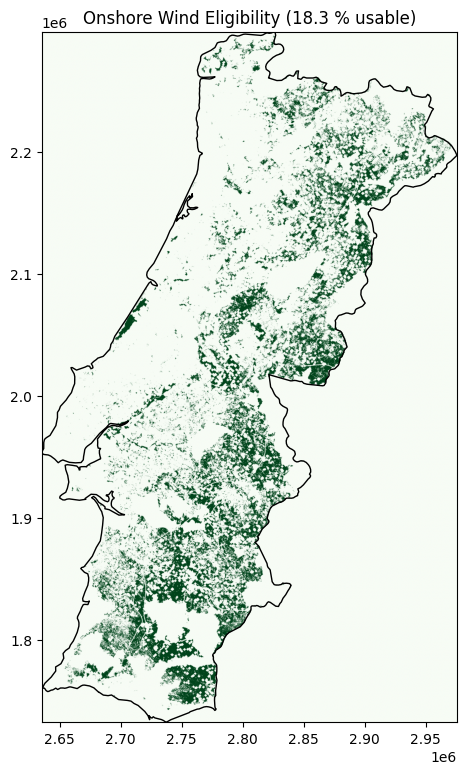

In [13]:
shape = gpd.GeoSeries([country_shape.union_all()], crs = 3035) # [EPSG:3035, m], all regions together as one shape
masked, transform = shape_availability(shape, exc_wind) # [-], using exclusion container on the shape (masked: 1 is suitable, 0 is excluded)
eligible_share = masked.sum() * exc_wind.res**2 / shape.area[0] # [-], ratio of usable area for wind onshore

#plot
fig, ax = plt.subplots(figsize=(5, 8))
ax = rasterio.plot.show(masked, transform = transform, cmap = 'Greens', ax = ax)
shape.plot(ax = ax, edgecolor = 'k', color = 'none', linewidth = 1)
ax.set_title(f'Onshore Wind Eligibility ({eligible_share*100:.1f} % usable)')

plt.tight_layout()
plt.show()

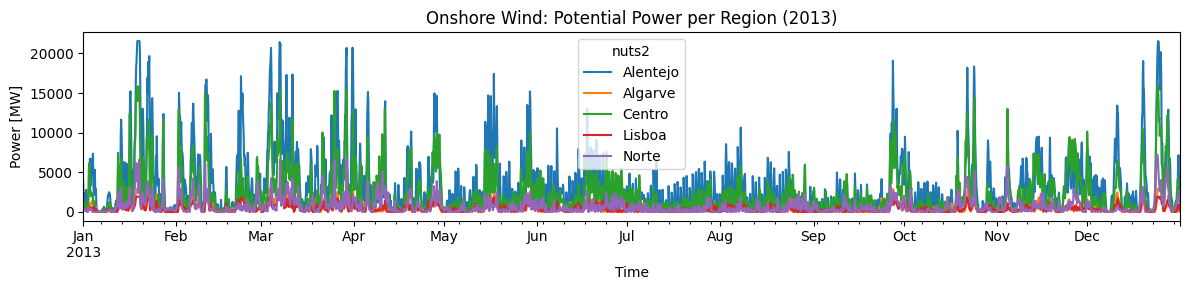

In [14]:
#potential feed-in per region: capacity factor x max installable capacity (3 MW/km2)
pot_wind = cf_wind.to_pandas() * (wind_eligible * 3.0) # [MW]
pot_wind.plot(figsize = (12, 3), title = 'Onshore Wind: Potential Power per Region (2013)')

plt.ylabel('Power [MW]')
plt.xlabel('Time')
plt.tight_layout()
plt.show()

#### 2.3.2 Wind offshore

First, the geoemtrical separation of the offshore area per region has to be completed

In [15]:
#filter offshore area EEZ minus 10km coastal buffer
land_geom = country_shape.union_all()
eez_geom = eez_mainland.union_all()
offshore_area = eez_geom.difference(land_geom.buffer(10000)) # [m], add coastal buffer to eez geometry

#EEZ region as polygon is split as 2km x 2km cells to assign it to the nearest region (sjoin_nearest)
minx, miny, maxx, maxy = offshore_area.bounds # [m]
step = 2000 # [m], grid cell size

cells_grid = [shp_box(x, y, x + step, y + step)
              for x in np.arange(minx, maxx, step)
              for y in np.arange(miny, maxy, step)]

grid = gpd.GeoDataFrame(geometry = cells_grid, crs = 3035)
grid['geometry'] = grid.geometry.intersection(offshore_area) #cells outside EEZ are cut off
grid = grid[~grid.geometry.is_empty].reset_index(drop = True) #remove empty cells

cent = grid.copy()
cent['geometry'] = grid.geometry.centroid #centroid for eevery cell of the grid
cent = gpd.sjoin_nearest(cent, regions[['geometry']].reset_index(), how = 'left') #assigne centroid the nearest NUTS2 region
grid['nuts2'] = cent['nuts2'].values

#merge all cells of same region
offshore_gdf = grid.dissolve(by = 'nuts2')[['geometry']]
offshore_gdf.index.name = 'nuts2'

print('Offshore regions:', offshore_gdf.index.tolist())
print(offshore_gdf)

Offshore regions: ['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte']
                                                   geometry
nuts2                                                      
Alentejo  POLYGON ((2593414.641 1832530.887, 2591414.641...
Algarve   POLYGON ((2335414.641 1704530.887, 2335414.641...
Centro    POLYGON ((2335414.641 2066530.887, 2335414.641...
Lisboa    POLYGON ((2335414.641 1878530.887, 2335414.641...
Norte     POLYGON ((2413414.641 2296530.887, 2411414.641...


Secondly, criteria for exclusion of potential offshore wind area has to be defined and eligible area selected

In [16]:
#criteria for exclusion of area are collected within the container
exc_off = ExclusionContainer(crs = 3035, res = 100) # [m], res = raster resolution

exc_off.add_raster(fn_wdpa_local, codes = [1], crs = 'ESRI:54009') #protected areas - none
exc_off.add_geometry(country_shape.geometry, buffer = 10000) # [m], distance to coast - 10km

offshore_valid = offshore_gdf #eligible area per region
avail_offshore = cutout.availabilitymatrix(offshore_valid.geometry, exc_off) # [-], fraction 0..1
offshore_eligible = eligible_area_km2(avail_offshore) # [km2]
offshore_eligible.index = offshore_valid.index

#capacity factor calculation basd on reference turbine
cf_offshore = cutout.wind(turbine = 'NREL_ReferenceTurbine_5MW_offshore',
                           matrix = avail_to_matrix(avail_offshore),
                           index = offshore_valid.index, per_unit = True).resample(time = '3h').mean() # [-], capacity factor, mean for 3 hourly resolution

print('Offshore wind eligible [km2]:')
print(offshore_eligible.round(0))

Offshore wind eligible [km2]:
nuts2
Alentejo     1838.0
Algarve     27822.0
Centro      21857.0
Lisboa      19343.0
Norte       13304.0
dtype: float64


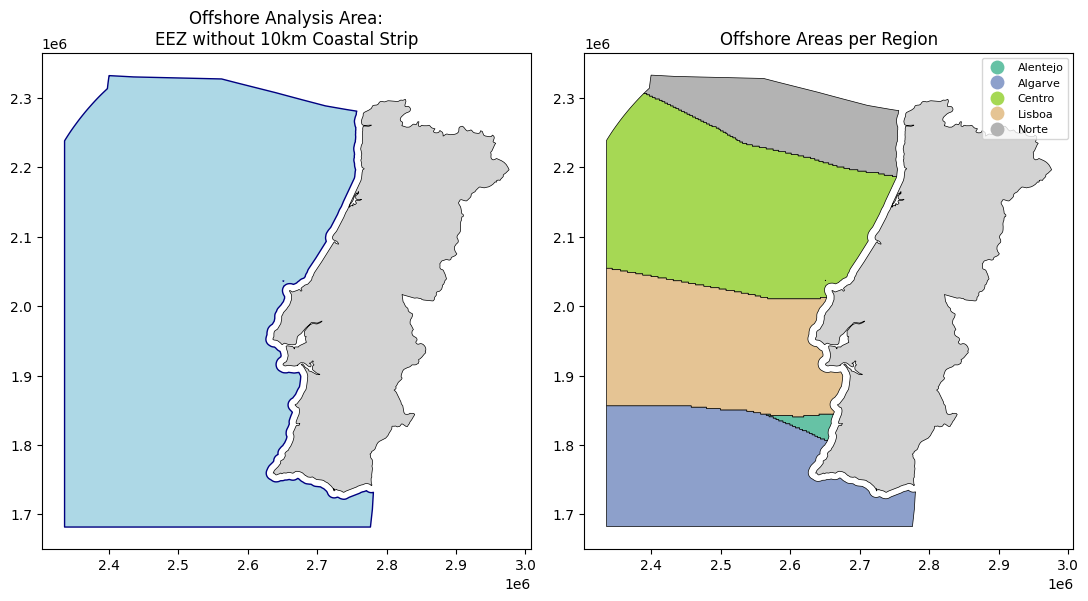

In [17]:
#Plot illustrating offshore area and its assignment to the regions defined above
fig, axes = plt.subplots(1, 2, figsize = (11, 8))

# Left: EEZ without 10km coastal strip
gpd.GeoSeries([offshore_area], crs = 3035).plot(ax = axes[0], color = 'lightblue', edgecolor = 'navy')
country_shape.plot(ax = axes[0], color = 'lightgrey', edgecolor = 'k', linewidth = 0.5)
axes[0].set_title('Offshore Analysis Area:\nEEZ without 10km Coastal Strip')

# Right: 2km cells assigned to nearest NUTS-2 region
offshore_gdf.reset_index().plot(
    ax = axes[1], column = 'nuts2', cmap = 'Set2',
    edgecolor = 'k', linewidth = 0.5, legend = True,
    legend_kwds = {'loc': 'upper right', 'fontsize': 8}
    )

country_shape.plot(ax = axes[1], color = 'lightgrey', edgecolor = 'k', linewidth = 0.5)
axes[1].set_title('Offshore Areas per Region')

plt.tight_layout()
plt.show()

Plotting the results of the capacity calculations

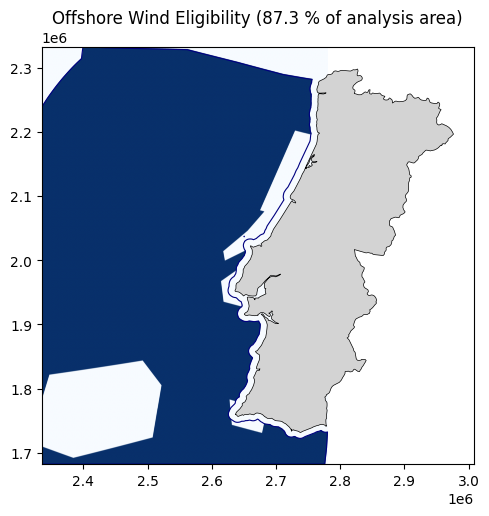

In [18]:
shape_off = gpd.GeoSeries([offshore_area], crs = 3035) # [EPSG:3035, m], all areas together as one shape
masked_off, transform_off = shape_availability(shape_off, exc_off) # [-], using exclusion container on the shape (masked: 1 is suitable, 0 is excluded)
eligible_share_off = masked_off.sum() * exc_off.res**2 / shape_off.area[0]  # [-], ratio of usable area for wind offshore

#plot
fig, ax = plt.subplots(figsize = (5, 8))
ax = rasterio.plot.show(masked_off, transform = transform_off, cmap = 'Blues', ax = ax)
shape_off.plot(ax = ax, edgecolor = 'navy', color = 'none', linewidth = 0.8)
country_shape.plot(ax = ax, color = 'lightgrey', edgecolor = 'k', linewidth = 0.5)
ax.set_title(f'Offshore Wind Eligibility ({eligible_share_off*100:.1f} % of analysis area)')

plt.tight_layout()
plt.show()

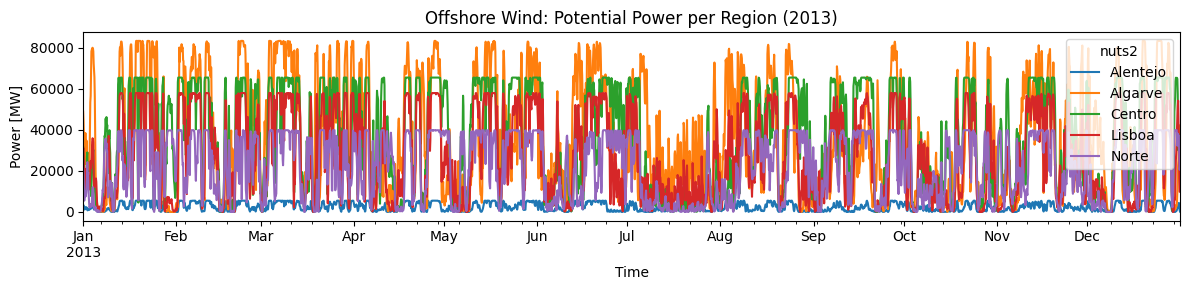

In [19]:
#potential feed-in per region: capacity factor x max installable capacity (3 MW/km2)
pot_off = cf_offshore.to_pandas() * (offshore_eligible * 3.0) # [MW]
pot_off.plot(figsize = (12, 3), title = 'Offshore Wind: Potential Power per Region (2013)')

plt.ylabel('Power [MW]')
plt.xlabel('Time')
plt.tight_layout()
plt.show()

#### 2.3.3 Solar PV

In [20]:
#crtieria for solar pv are stored within a container
exc_solar = ExclusionContainer(crs = 3035, res = 100) # [m], res = raster resolution

exc_solar.add_raster(fn_wdpa_local, codes = [1], crs = 'ESRI:54009') #protected areas - none
exc_solar.add_raster(fn_glc, codes = excluded_lc, crs = 4326, nodata = 255)  #exclude unsuitable land cover

avail_solar = cutout.availabilitymatrix(regions.geometry, exc_solar) # [-], fraction 0..1
solar_eligible = eligible_area_km2(avail_solar) # [km2], eligible area for solar pv
solar_eligible.index = regions.index

#capacity factor calculation based on reeference solar panel with optimal latitude ortientation
cf_solar = cutout.pv(panel = 'CdTe', orientation = 'latitude_optimal',
                     matrix = avail_to_matrix(avail_solar),
                     index = regions.index, per_unit = True).resample(time = '3h').mean() # [-], capacity factor, mean for 3 hourly resolution

print('Solar PV eligible [km2]:')
print(solar_eligible.round(0))

Solar PV eligible [km2]:
nuts2
Alentejo     9658.0
Algarve      1812.0
Centro      10807.0
Lisboa       2029.0
Norte        4905.0
dtype: float64


Plotting results of eligibility analysis for solar pv

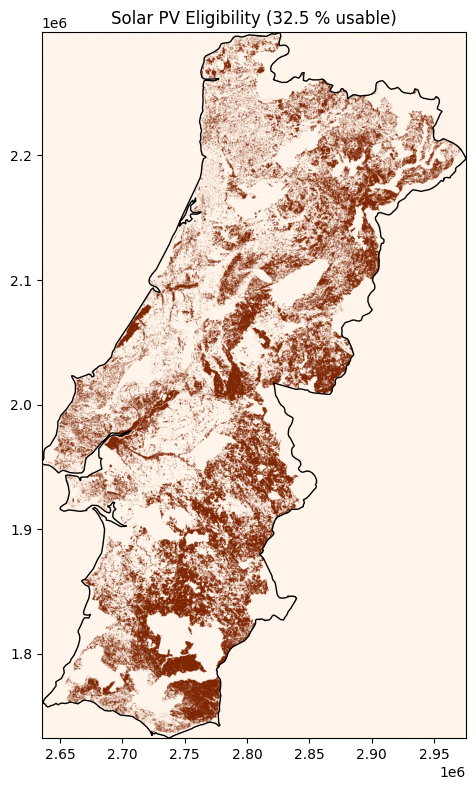

In [21]:
masked_sol, transform_sol = shape_availability(shape, exc_solar) # [-], 1 = suitable, 0 = excluded
eligible_share_sol = masked_sol.sum() * exc_solar.res**2 / shape.area[0] # [-], ratio of usable area for solar pv

#plot
fig, ax = plt.subplots(figsize = (5, 8))
ax = rasterio.plot.show(masked_sol, transform = transform_sol, cmap = 'Oranges', ax = ax)
shape.plot(ax = ax, edgecolor = 'k', color = 'none', linewidth = 1)
ax.set_title(f'Solar PV Eligibility ({eligible_share_sol*100:.1f} % usable)')

plt.tight_layout()
plt.show()

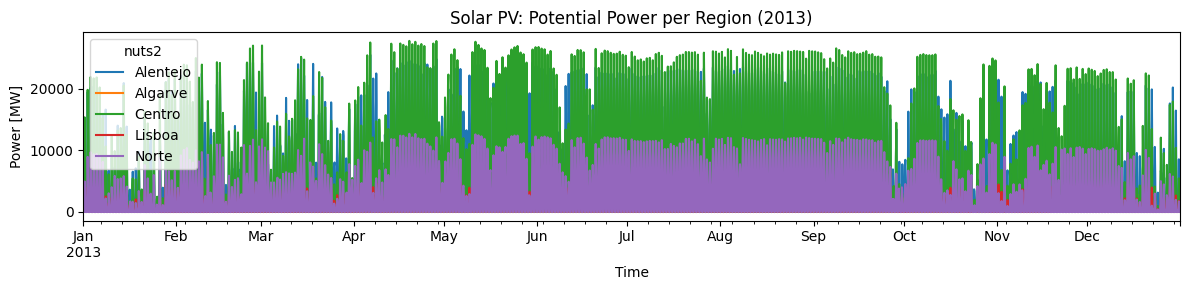

In [22]:
#potential feed-in per region: capacity factor x max installable capacity (3 MW/km2)
pot_solar = cf_solar.to_pandas() * (solar_eligible * 3.0) # [MW]
pot_solar.plot(figsize = (12, 3), title = 'Solar PV: Potential Power per Region (2013)')

plt.ylabel('Power [MW]')
plt.xlabel('Time')
plt.tight_layout()
plt.show()

### 2.4 Calculating max. capacities to be installed

In [23]:
deployment_density = 3.0 # [MW/km2], deployment density

p_nom_max_wind = wind_eligible * deployment_density # [MW], max. onshore wind capacities
p_nom_max_offshore = offshore_eligible * deployment_density # [MW], max. offshore wind capacities
p_nom_max_solar = solar_eligible * deployment_density # [MW], max. solar PV capacities

print('p_nom_max wind [MW]:')
print(p_nom_max_wind.round(0))

print('p_nom_max offshore [MW]:')
print(p_nom_max_offshore.round(0))

print('p_nom_max solar [MW]:')
print(p_nom_max_solar.round(0))

p_nom_max wind [MW]:
nuts2
Alentejo    21585.0
Algarve      2975.0
Centro      16000.0
Lisboa       1931.0
Norte        7217.0
dtype: float64
p_nom_max offshore [MW]:
nuts2
Alentejo     5513.0
Algarve     83465.0
Centro      65570.0
Lisboa      58029.0
Norte       39912.0
dtype: float64
p_nom_max solar [MW]:
nuts2
Alentejo    28973.0
Algarve      5437.0
Centro      32421.0
Lisboa       6086.0
Norte       14715.0
dtype: float64


Illustrating potential capacities per technology and region

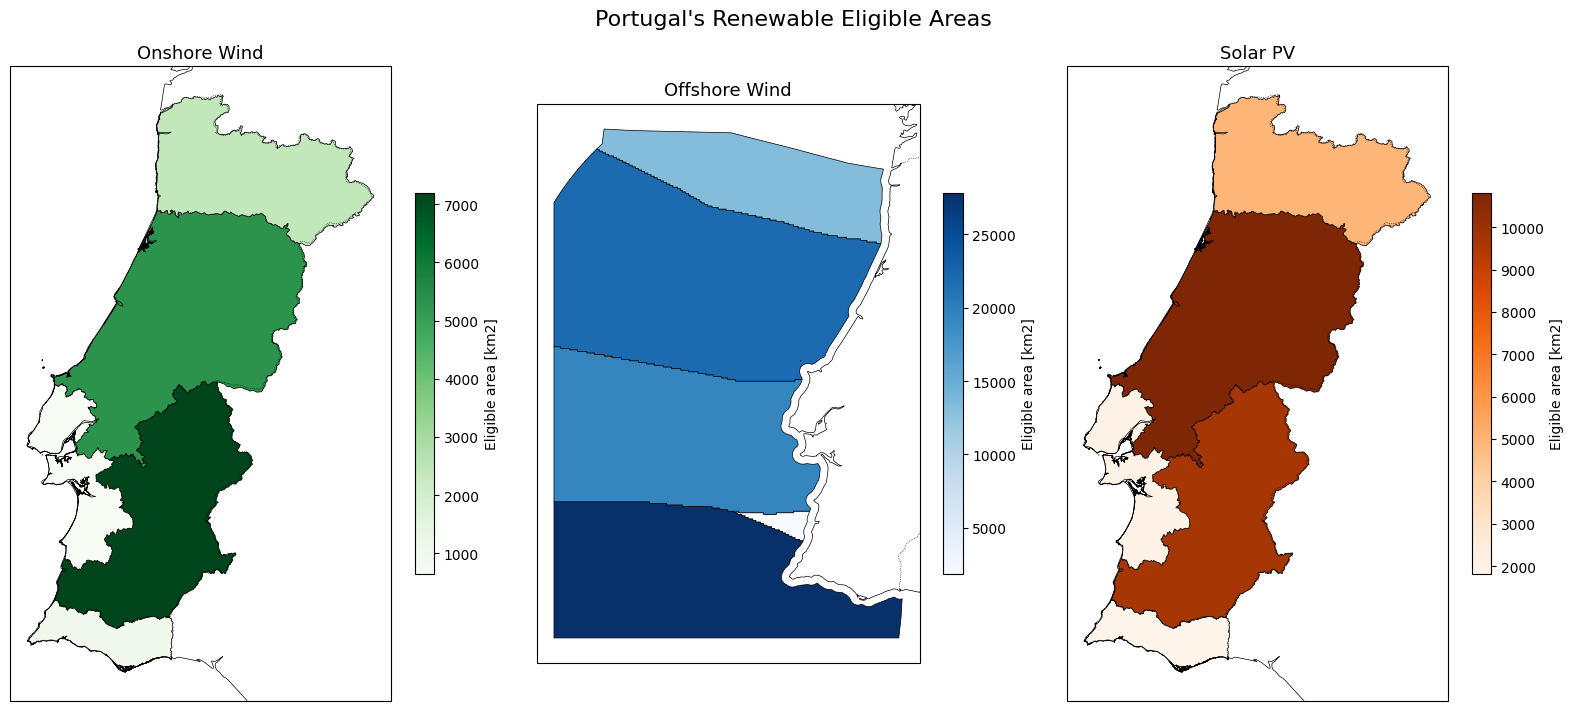

In [24]:
fig, axes = plt.subplots(1, 3, figsize = (16, 7), subplot_kw = {'projection': ccrs.epsg(3035)})

for ax, title, gdf, elig, cmap in zip(
    axes,
    ['Onshore Wind', 'Offshore Wind', 'Solar PV'],
    [regions, offshore_valid, regions],
    [wind_eligible, offshore_eligible, solar_eligible],
    ['Greens', 'Blues', 'Oranges']
):
    g = gdf.copy(); g['eligible_km2'] = elig.values
    g.plot(ax = ax, column = 'eligible_km2', cmap = cmap, legend = True,
           legend_kwds = {'label': 'Eligible area [km2]', 'shrink': 0.6},
           edgecolor = 'k', linewidth = 0.5)
    ax.coastlines(resolution = '10m', linewidth = 0.5)
    ax.add_feature(cartopy.feature.BORDERS, linewidth = 0.5, linestyle = ':')
    ax.set_title(title, fontsize = 13)

plt.suptitle('Portugal\'s Renewable Eligible Areas', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('eligible_areas_portugal.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## Export — save data for PyPSA.ipynb

In [25]:
#regions 
regions.drop(columns = ['representative_point']).to_file('regions.gpkg', driver = 'GPKG') # [EPSG:3035, m]
offshore_valid.to_file('offshore_valid.gpkg', driver = 'GPKG') # [EPSG:3035, m]
eez_mainland.to_file('eez_mainland.gpkg', driver = 'GPKG') # [EPSG:3035, m]

#capacity factor time series (xarray -> netCDF)
cf_wind.to_netcdf('cf_wind.nc') # [-], per-unit, 3 hour resolution
cf_solar.to_netcdf('cf_solar.nc') # [-], per-unit, 3 hour resolution
cf_offshore.to_netcdf('cf_offshore.nc') # [-], per-unit, 3 hour resolution

#p_nom_max (pandas Series -> CSV)
p_nom_max_wind.to_csv('p_nom_max_wind.csv', header = ['p_nom_max_MW']) # [MW]
p_nom_max_solar.to_csv('p_nom_max_solar.csv', header = ['p_nom_max_MW']) # [MW]
p_nom_max_offshore.to_csv('p_nom_max_offshore.csv', header = ['p_nom_max_MW']) # [MW]

print('All outputs saved')

All outputs saved
